In [49]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

plt.style.use("dark_background")

In [50]:
df = yf.download('AAPL', start='2018-01-01', end='2024-01-01')
prices = df['Close']['AAPL']
prices.to_csv('../data/aapl_prices.csv')
print(prices.head())
print(prices.shape)

[*********************100%***********************]  1 of 1 completed

Date
2018-01-02    40.267090
2018-01-03    40.260063
2018-01-04    40.447067
2018-01-05    40.907558
2018-01-08    40.755638
Name: AAPL, dtype: float64
(1509,)


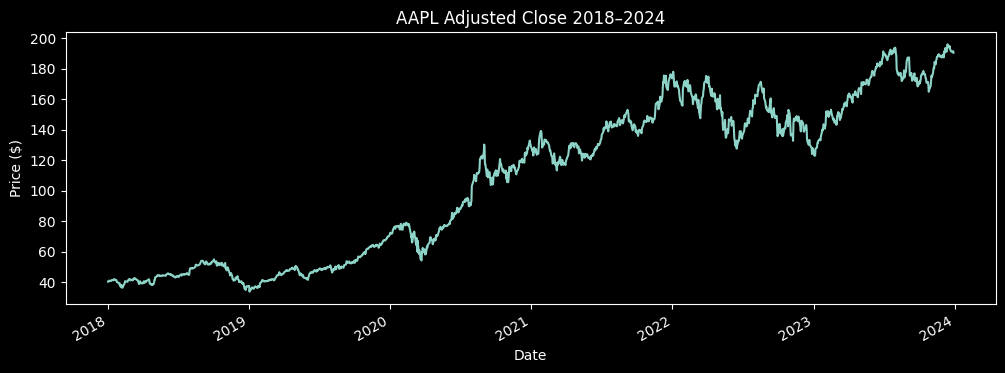

In [51]:
prices.plot(figsize=(12, 4), title='AAPL Adjusted Close 2018–2024')
plt.ylabel('Price ($)')
plt.show()

In [52]:
returns = np.log(prices / prices.shift(1)).dropna()
target = returns.shift(-1).dropna()
returns = returns[returns.index.isin(target.index)]
print(returns.shape, target.shape)

(1507,) (1507,)


In [53]:
print(f"Returns shape: {returns.shape}")
print(f"Target shape: {target.shape}")
print(f"Any NaN in returns: {returns.isna().any()}")
print(f"Any NaN in target: {target.isna().any()}")
print(f"\nFirst 5 returns:\n{returns.head()}")
print(f"\nFirst 5 targets:\n{target.head()}")

Returns shape: (1507,)
Target shape: (1507,)
Any NaN in returns: False
Any NaN in target: False

First 5 returns:
Date
2018-01-03   -0.000175
2018-01-04    0.004634
2018-01-05    0.011321
2018-01-08   -0.003721
2018-01-09   -0.000115
Name: AAPL, dtype: float64

First 5 targets:
Date
2018-01-03    0.004634
2018-01-04    0.011321
2018-01-05   -0.003721
2018-01-08   -0.000115
2018-01-09   -0.000229
Name: AAPL, dtype: float64


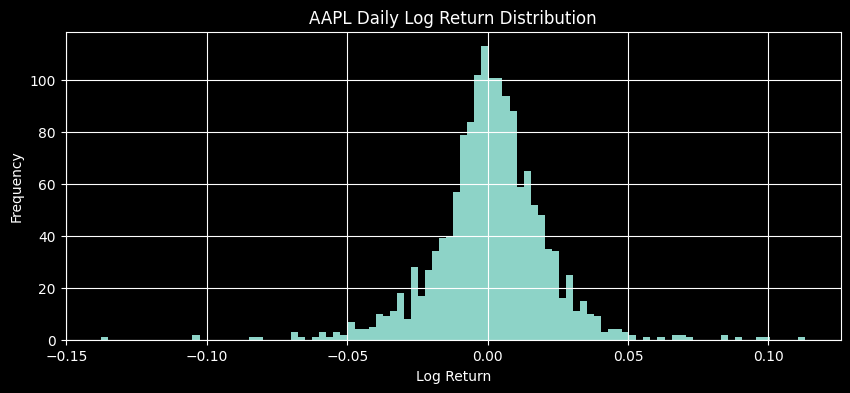

In [54]:
returns.hist(bins=100, figsize=(10, 4))
plt.title('AAPL Daily Log Return Distribution')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.show()

In [55]:
features = pd.DataFrame(index=prices.index)
sma5  = prices.rolling(5).mean()
sma20 = prices.rolling(20).mean()
sma50 = prices.rolling(50).mean()
ema12 = prices.ewm(span=12).mean()
ema26 = prices.ewm(span=26).mean()
price_vs_sma20 = (prices / sma20) - 1
sma_crossover  = (sma5 > sma20).astype(int)
macd           = ema12 - ema26
macd_signal    = macd.ewm(span=9).mean()
features['sma5']           = sma5
features['sma20']          = sma20
features['sma50']          = sma50
features['ema12']          = ema12
features['ema26']          = ema26
features['price_vs_sma20'] = price_vs_sma20
features['sma_crossover']  = sma_crossover
features['macd']           = macd
features['macd_signal']    = macd_signal
print(features.shape)
print(features.head(10))

(1509, 9)
                 sma5  sma20  sma50      ema12      ema26  price_vs_sma20  \
Date                                                                        
2018-01-02        NaN    NaN    NaN  40.267090  40.267090             NaN   
2018-01-03        NaN    NaN    NaN  40.263284  40.263441             NaN   
2018-01-04        NaN    NaN    NaN  40.335014  40.329416             NaN   
2018-01-05        NaN    NaN    NaN  40.515744  40.491040             NaN   
2018-01-08  40.527483    NaN    NaN  40.580923  40.552401             NaN   
2018-01-09  40.624255    NaN    NaN  40.622248  40.592169             NaN   
2018-01-10  40.720564    NaN    NaN  40.648882  40.618745             NaN   
2018-01-11  40.825755    NaN    NaN  40.716526  40.675829             NaN   
2018-01-12  40.923466    NaN    NaN  40.850972  40.782590             NaN   
2018-01-16  41.009488    NaN    NaN  40.914412  40.838222             NaN   

            sma_crossover      macd  macd_signal  
Date          

In [56]:
print(f"First 5 rows of sma50 (should be NaN):\n{sma50.head()}")
print(f"\nFirst non-NaN row of sma50: {sma50.first_valid_index()}")
print(f"\nNaN counts per feature:\n{features.isna().sum()}")

First 5 rows of sma50 (should be NaN):
Date
2018-01-02   NaN
2018-01-03   NaN
2018-01-04   NaN
2018-01-05   NaN
2018-01-08   NaN
Name: AAPL, dtype: float64

First non-NaN row of sma50: 2018-03-14 00:00:00

NaN counts per feature:
sma5               4
sma20             19
sma50             49
ema12              0
ema26              0
price_vs_sma20    19
sma_crossover      0
macd               0
macd_signal        0
dtype: int64


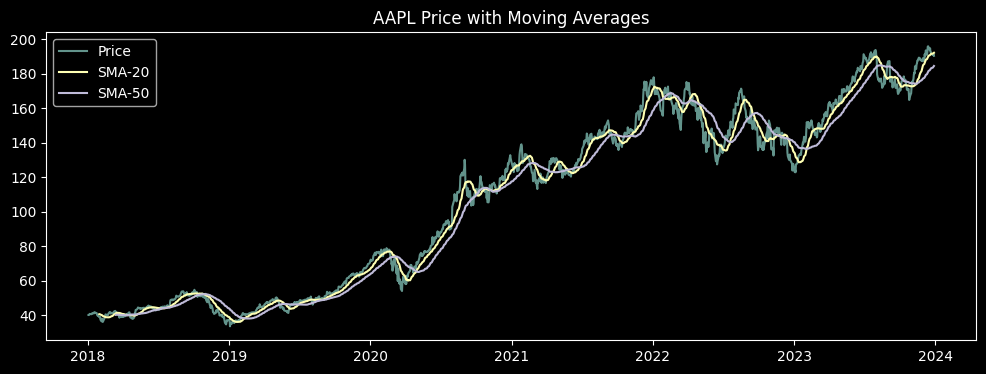

In [57]:
plt.figure(figsize=(12, 4))
plt.plot(prices, label='Price', alpha=0.7)
plt.plot(sma20, label='SMA-20')
plt.plot(sma50, label='SMA-50')
plt.title('AAPL Price with Moving Averages')
plt.legend()
plt.show()

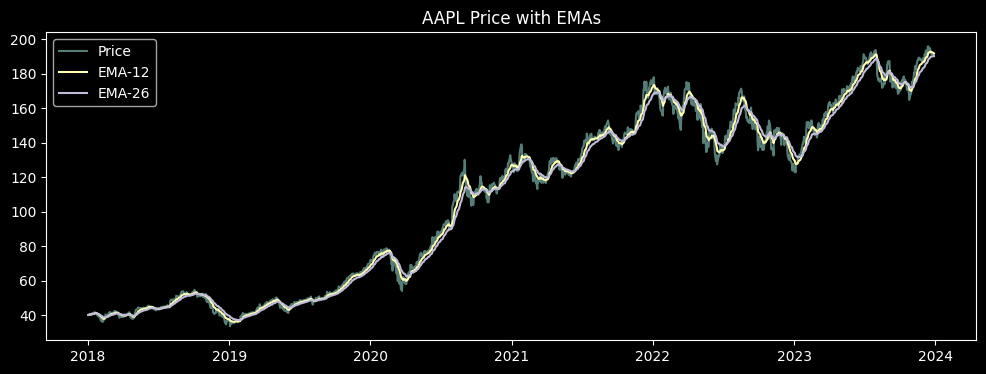

In [58]:
plt.figure(figsize=(12, 4))
plt.plot(prices, label='Price', alpha=0.6)
plt.plot(ema12, label='EMA-12')
plt.plot(ema26, label='EMA-26')
plt.title('AAPL Price with EMAs')
plt.legend()
plt.show()

In [59]:
delta = prices.diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()

rs = avg_gain / avg_loss
rsi = 100 - (100 / (1 + rs))

features['rsi_14'] = rsi

print(f"RSI min: {rsi.min():.2f}, max: {rsi.max():.2f}")
print(rsi.head(20))
print(f"Checking if all RSI values are greater than zero: {(rsi > 0).all()}")
print(f"RSI min: {rsi.min():.2f}")
print(f"RSI max: {rsi.max():.2f}")
print(f"NaN count: {rsi.isna().sum()}")
print(rsi.head(10))

RSI min: 0.00, max: 88.20
Date
2018-01-02          NaN
2018-01-03     0.000000
2018-01-04    67.182875
2018-01-05    88.202126
2018-01-08    71.851580
2018-01-09    71.411630
2018-01-10    70.485093
2018-01-11    78.071897
2018-01-12    85.440329
2018-01-16    72.411494
2018-01-17    81.980460
2018-01-18    82.343034
2018-01-19    74.292374
2018-01-22    62.318241
2018-01-23    62.496510
2018-01-24    45.975288
2018-01-25    34.989702
2018-01-26    37.072359
2018-01-29    28.382097
2018-01-30    26.515369
Name: AAPL, dtype: float64
Checking if all RSI values are greater than zero: False
RSI min: 0.00
RSI max: 88.20
NaN count: 1
Date
2018-01-02          NaN
2018-01-03     0.000000
2018-01-04    67.182875
2018-01-05    88.202126
2018-01-08    71.851580
2018-01-09    71.411630
2018-01-10    70.485093
2018-01-11    78.071897
2018-01-12    85.440329
2018-01-16    72.411494
Name: AAPL, dtype: float64


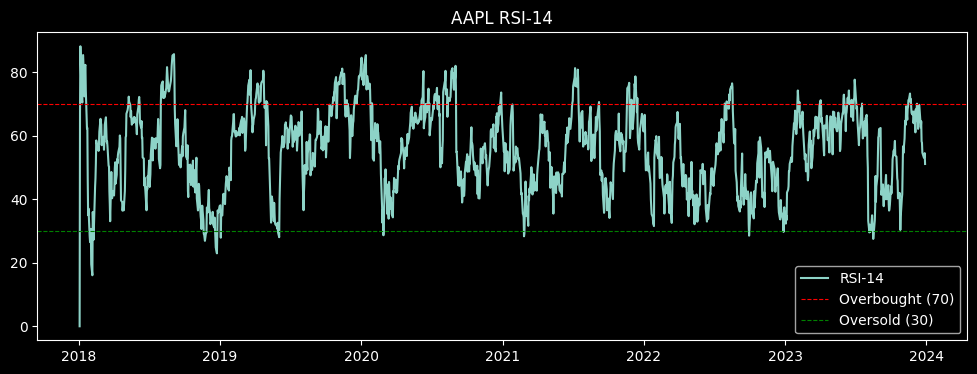

In [60]:
plt.figure(figsize=(12, 4))
plt.plot(rsi, label='RSI-14')
plt.axhline(70, color='red', linestyle='--', linewidth=0.8, label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
plt.title('AAPL RSI-14')
plt.legend()
plt.show()

In [71]:
# Volatility features — on RETURNS
vol20 = returns.rolling(20).std() * np.sqrt(252)
vol5  = returns.rolling(5).std() * np.sqrt(252)
vol_ratio = vol5 / vol20

# Bollinger Bands — on PRICES
std20      = prices.rolling(20).std()
BB_middle  = sma20
BB_upper   = BB_middle + 2 * std20
BB_lower   = BB_middle - 2 * std20
BB_percent = (prices - BB_lower) / (BB_upper - BB_lower)
bandwidth  = (BB_upper - BB_lower) / BB_middle

# Volume
volume = df['Volume']['AAPL']
volume_ratio = volume / volume.rolling(20).mean()

# Add to features
features['vol20'] = vol20
features['vol5'] = vol5
features['vol_ratio'] = vol_ratio
features['BB_middle'] = BB_middle
features['BB_upper'] = BB_upper
features['BB_lower'] = BB_lower
features['BB_percent'] = BB_percent
features['Bandwith'] = Bandwith
features['volume_ratio'] = volume_ratio


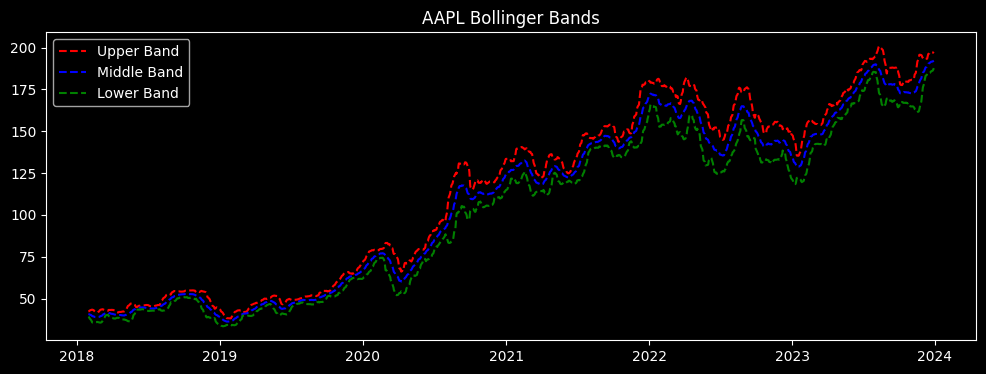

In [72]:
plt.figure(figsize=(12, 4))

plt.plot(BB_upper, label='Upper Band', linestyle='--', color='red')
plt.plot(BB_middle, label='Middle Band', linestyle='--', color='blue')
plt.plot(BB_lower, label='Lower Band', linestyle='--', color='green')
plt.title('AAPL Bollinger Bands')
plt.legend()
plt.show()

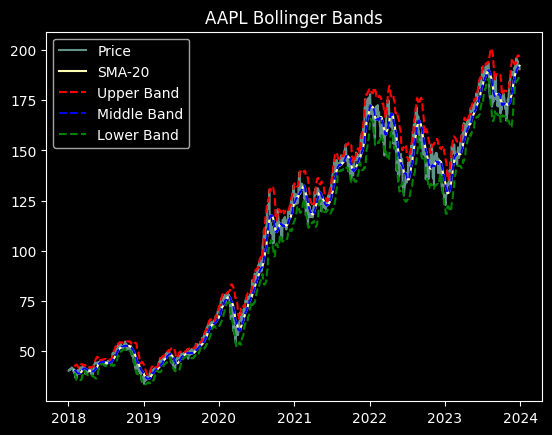

In [73]:
plt.plot(prices, label='Price', alpha=0.7)
plt.plot(sma20, label='SMA-20')
plt.plot(BB_upper, label='Upper Band', linestyle='--', color='red')
plt.plot(BB_middle, label='Middle Band', linestyle='--', color='blue')
plt.plot(BB_lower, label='Lower Band', linestyle='--', color='green')
plt.title('AAPL Bollinger Bands')
plt.legend()
plt.show()